In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import init_printing
import sympy as sym
from scipy.integrate import solve_ivp
import networkx as nx
#init_printing()

Problem 1

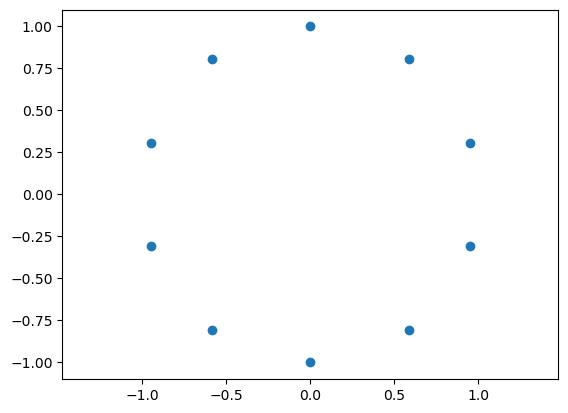

In [13]:
N = 10
theta = np.linspace(0,2*np.pi,N+1)[:N]
formation_x = np.sin(theta)
formation_y = np.cos(theta)
formation = np.asarray([formation_x,formation_y])
plt.scatter(formation_x,formation_y)
plt.axis("equal")
plt.show()

array([[-0.15184804,  0.44299859,  0.20723885, -0.80572665,  0.41757961,
        -0.4910255 ,  0.56657172,  0.29240412, -0.23959925,  0.81885699],
       [-0.68037604, -0.00134167, -0.55004119,  0.40383515,  0.5028463 ,
        -0.24750195,  0.8603207 , -0.54415335,  0.2578112 , -0.34766895]])

In [38]:
def get_D_L(A):
    n = A.shape[1]
    D = np.diag([sum(A[i,:]) for i in range(n)]) # i LOVE list comprehensions, even though would probably be faster to do something like np.diag(A@np.ones(n))
    L = D-A
    return D,L


G = nx.cycle_graph(10)
A = nx.adjacency_matrix(G).toarray()

D,L = get_D_L(A)

w = np.zeros_like(A,float) # float is important or everything gets screwed up, rounded to ints
for i in range(N):
    for j in range(N):
        if i != j and A[i,j] == 1:
            w[i,j] = 1 / (1 + max(D[i,i], D[j,j]))
    w[i,i] = 1 - np.sum(w[i,:])  # diagonal ensures row sum = 1

sym.Matrix(w)

Matrix([
[0.333333333333333, 0.333333333333333,               0.0,               0.0,               0.0,               0.0,               0.0,               0.0,               0.0, 0.333333333333333],
[0.333333333333333, 0.333333333333333, 0.333333333333333,               0.0,               0.0,               0.0,               0.0,               0.0,               0.0,               0.0],
[              0.0, 0.333333333333333, 0.333333333333333, 0.333333333333333,               0.0,               0.0,               0.0,               0.0,               0.0,               0.0],
[              0.0,               0.0, 0.333333333333333, 0.333333333333333, 0.333333333333333,               0.0,               0.0,               0.0,               0.0,               0.0],
[              0.0,               0.0,               0.0, 0.333333333333333, 0.333333333333333, 0.333333333333333,               0.0,               0.0,               0.0,               0.0],
[              0.0,            

In [52]:
formation[:,0]

array([0., 1.])

In [ ]:
def DGD(x,kmax,alpha):
    x_list = [x.copy()]
    for k in range(kmax):
        for i in range(N):
            lst = []
            for j in range(N):
                lst.append(w[i,j]*x[:,j]) 
            x[:,i] = sum(lst) - alpha(k)*(x[:,i]-formation[:,i])
        x_list.append(x.copy())
    return x_list

def alpha_const_1(k):
    return 0.01

def alpha_const_2(k):
    return 0.01



def alpha_harm(k):
    return 1/(1+k)

def plot_trajectories(x_list,title = "DGD Trajectories of Agents"):
    x_array = np.array(x_list)
    N = x_array.shape[2]

    plt.figure(figsize=(7,6))
    for i in range(N):
        traj = x_array[:,:,i]  # shape (kmax+1, 2)
        plt.plot(traj[:,0], traj[:,1], marker='o', markersize=1.5, label=f'Agent {i+1}')

    plt.title(title)
    plt.grid()
    plt.legend(loc='upper right')
    plt.axis('equal')
    plt.show()

def plot_final_pos(x_lst):
    plt.scatter(x_lst[])

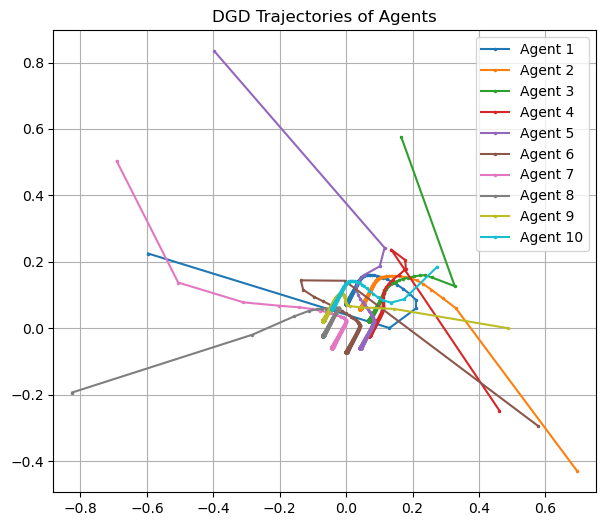

In [126]:
x = np.random.uniform(-1,1,(2,N))
kmax = 1000
xf = DGD(x,kmax,alpha_const_1) 
plot_trajectories(xf)

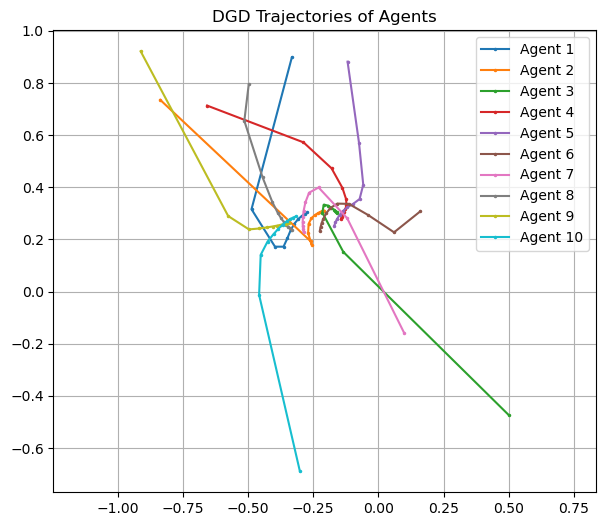

In [124]:
x = np.random.uniform(-1,1,(2,N))
kmax = 10
xf = DGD(x,kmax,alpha_const_2) 
plot_trajectories(xf)

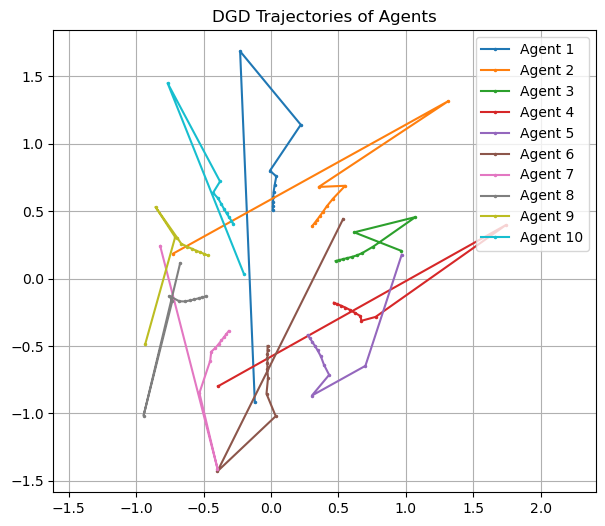

In [ ]:
x = np.random.uniform(-1,1,(2,N))
kmax = 10
xf = DGD(x,kmax,alpha_harm) 
plot_trajectories(xf)

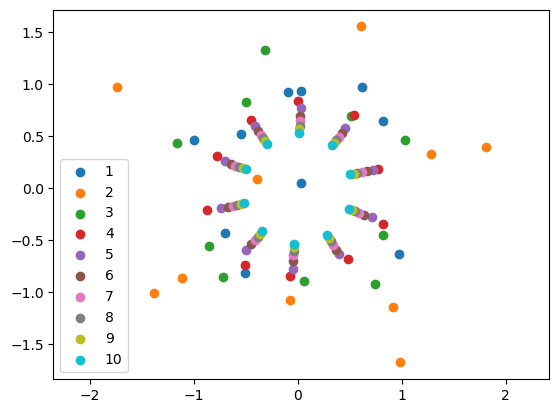

(-2.0348300283921477,
 1.1832617759465731,
 -1.8096039585187291,
 1.2972810753237702)

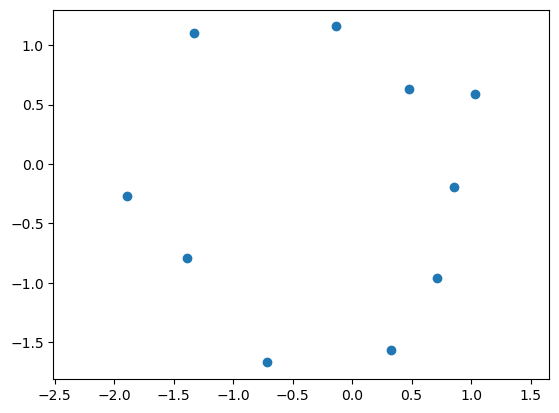

In [100]:
plt.scatter(xf[1][0],xf[1][1])
plt.axis("equal")